# MLflow avanzado: tracking + HPO (Optuna)

Este notebook tiene dos objetivos:

1) **Tracking (experimentos y runs)**
- Guardar parámetros, métricas, tags y artifacts (archivos como `.csv`, `.png`, etc.).
- Comparar resultados entre runs.

2) **Optimización de hiperparámetros (Optuna) con MLflow**
- Un *parent run* representa el estudio.
- Cada *trial* se guarda como un *child run* (`nested=True`).

> Nota importante (para no confundirse):
>
>- **Loggear un modelo** (`mlflow.<flavor>.log_model`) significa guardarlo como artifact *dentro de un run*.
>- **Registrar un modelo** (Model Registry) significa crear un nombre de “modelo” global con **versiones** (v1, v2, ...) que apuntan a runs.
>
> En este notebook el foco principal es **tracking + Optuna**. El Model Registry aparece al final como material complementario.

In [26]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


## **Cargamos datos "procesados"**

In [27]:
df_jan = pd.read_parquet("data/processed/jan.parquet")
df_feb = pd.read_parquet("data/processed/feb.parquet")


## **Definir columnas a modelar**

In [28]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ["trip_distance"]

## Definir set de train y test

In [29]:
df_train = df_jan
df_val = df_feb

## **Preprocesar**

In [30]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df_train = df_train.copy()
df_val   = df_val.copy()
df_train["categorical_dict"] = df_train[categorical].to_dict(orient="records")
df_val["categorical_dict"]   = df_val[categorical].to_dict(orient="records")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", DictVectorizer(), "categorical_dict"),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numerical),
    ]
)

X_train = preprocessor.fit_transform(df_train)
y_train = df_train["duration"].values
X_val   = preprocessor.transform(df_val)
y_val   = df_val["duration"].values

2026/03/17 20:59:24 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:59:24 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 20:59:24 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '279340477e3a4b3fac015d4e523f594c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/17 20:59:24 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/03/17 20:59:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:59:25 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inp

🏃 View run legendary-perch-714 at: http://127.0.0.1:5000/#/experiments/5/runs/279340477e3a4b3fac015d4e523f594c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


## **Entrenar**

Antes de ejecutar lo siguiente, levanta el **MLflow Tracking Server** en una terminal (en la raíz del proyecto):

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5000 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```

Luego abre la UI en:

- http://127.0.0.1:5000

## ¿Qué crea esto en tu proyecto?

- `mlflow.db`:
  - Base de datos (SQLite) con la **metadata** del tracking (experimentos, runs, params, metrics, etc.).

- `mlruns/`:
  - Carpeta donde MLflow guarda los **artifacts** (archivos) de cada run.
  - Dentro de cada run verás `artifacts/` (por ejemplo: predicciones, plots, modelos loggeados).

In [31]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5000'


## Cómo leer la carpeta `mlruns/` (muy importante)

Cuando ejecutas runs con MLflow, lo común es ver algo así:

- `mlruns/<experiment_id>/<run_id>/`:
  - `metrics/`, `params/`, `tags/`: archivos internos que MLflow usa para tracking.
  - `artifacts/`: **archivos que tú registras** (CSVs, PNGs, etc.).
    - Si haces `mlflow.<flavor>.log_model(..., name="model")`, MLflow guarda el modelo en:
      - `mlruns/<experiment_id>/<run_id>/artifacts/model/`

### ¿Y la carpeta `mlruns/models/`?

- Esa carpeta aparece cuando está habilitado el **Model Registry** (depende de cómo esté configurado el server/backend).
- No es “un modelo por run”. Es el **catálogo**:
  - Un **Registered Model** (un nombre)
  - Con varias **versiones** (v1, v2, ...) que apuntan a runs.

Regla mental:

- **Run** = una ejecución (con artifacts, incluyendo el modelo loggeado).
- **Registry** = un índice/catálogo que organiza “el mismo modelo” en versiones.

In [32]:

experiment_name = "nyc-first-experiment"

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="rf_baseline"):
    rf = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=10)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))

    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("random_state", 0)
    mlflow.log_metric("rmse", rmse)

    rmse

2026/03/17 20:59:25 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:59:25 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 20:59:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:59:31 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/17 20:59:31 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run rf_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/6e0d266711a0463088169d1a68556b12
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## **Probando otro modelo**

In [33]:
import xgboost as xgb

experiment_name = "nyc-taxi-baseline"
mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="xgb_baseline"):
    xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    xgb_reg.fit(X_train, y_train)
    y_pred = xgb_reg.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    mlflow.log_param("objective", "reg:squarederror")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("rmse", rmse)

    rmse

2026/03/17 20:59:31 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:59:31 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 20:59:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 20:59:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/mdurango/Downloads/proyectos/MLOps_UdM/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [20:59:31] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/03/17 20:59:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:59:32 INFO mlflow.sy

🏃 View run xgb_baseline at: http://127.0.0.1:5000/#/experiments/2/runs/40db6a012c4746d58295c28ad5518969
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


## **Probando autologging**

`mlflow.autolog()` captura automáticamente muchos parámetros, métricas y artifacts del entrenamiento.

Nota: MLflow puede mostrar warnings si la versión instalada de XGBoost no está dentro del rango recomendado para autologging.

In [49]:
import mlflow

experiment_name = "nyc-taxi-autolog"
mlflow.set_experiment(experiment_name)

mlflow.autolog()

mlflow.enable_system_metrics_logging()

with mlflow.start_run(run_name="rf_autolog") as run:
    rf = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=10)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    mlflow.log_metric("rmse_manual", rmse)


    rmse

print(mlflow.MlflowClient().get_run(run.info.run_id).data)

2026/03/17 21:17:27 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/03/17 21:17:27 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.0.0 <= xgboost <= 3.0.2, but the installed version is 3.0.4. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.
2026/03/17 21:17:27 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/03/17 21:17:27 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 21:17:27 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 21:17:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 21:17:33 INFO mlflow.system_metrics.system_metrics_monitor: Stop

🏃 View run rf_autolog at: http://127.0.0.1:5000/#/experiments/3/runs/ff2672880721454bb8812372dc200674
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
<RunData: metrics={'mean_squared_error_X_val': 26.39610224677387,
 'rmse_manual': 5.137713717868471,
 'training_mean_absolute_error': 3.11467202167165,
 'training_mean_squared_error': 22.407621803552562,
 'training_r2_score': 0.7248164394449219,
 'training_root_mean_squared_error': 4.7336689579598366,
 'training_score': 0.7248164394449219}, params={'bootstrap': 'True',
 'ccp_alpha': '0.0',
 'criterion': 'squared_error',
 'max_depth': '10',
 'max_features': '1.0',
 'max_leaf_nodes': 'None',
 'max_samples': 'None',
 'min_impurity_decrease': '0.0',
 'min_samples_leaf': '1',
 'min_samples_split': '2',
 'min_weight_fraction_leaf': '0.0',
 'monotonic_cst': 'None',
 'n_estimators': '100',
 'n_jobs': 'None',
 'oob_score': 'False',
 'random_state': '0',
 'verbose': '0',
 'warm_start': 'False'}, tags={'estimator_class': 'sklearn.ensembl

In [ ]:
from mlflow.tracking import MlflowClient
client = MlflowClient()
 
run_id = "76a4a1160e73474398d4dd8aa821615e" # reemplazar con el run_id del experimento
client.list_artifacts(run_id)
client.list_artifacts(run_id, path="model")

[<FileInfo: file_size=990, is_dir=False, path='model/MLmodel'>,
 <FileInfo: file_size=221, is_dir=False, path='model/conda.yaml'>,
 <FileInfo: file_size=11139689, is_dir=False, path='model/model.pkl'>,
 <FileInfo: file_size=99, is_dir=False, path='model/python_env.yaml'>,
 <FileInfo: file_size=107, is_dir=False, path='model/requirements.txt'>]

## **Optimización de Hiperparametros**

## **Usando Optuna + MLflow (nested runs)**

En esta sección:

- Creamos un *parent run* que representa el estudio completo.
- Cada trial se guarda como un *child run* (`nested=True`).
- Loggeamos artifacts útiles: `optuna_top_trials.csv` y `optuna_best_params.json`.

Así, en la UI de MLflow puedes ver el estudio completo y, dentro, cada trial con sus hiperparámetros y métrica.

Optimizar los hiperparámetros no es solo cuestión de probar al azar: es un proceso sistemático para encontrar la mejor combinación posible, y así lograr que nuestro modelo aprenda mejor y generalice bien a datos nuevos. Si no los ajustamos, podemos quedarnos con un modelo que no aprovecha todo su potencial.

## **Usando Optuna**

Optuna prueba combinaciones de hiperparámetros, aprende de los resultados y se enfoca en las opciones más prometedoras, ahorrando tiempo y esfuerzo.

En este notebook, además de optimizar, vamos a **registrar cada trial en MLflow** para poder comparar en la UI.

(Opcional) Puedes ignorar este diagrama. Lo importante es que Optuna explorará hiperparámetros y MLflow guardará los resultados de cada trial.

## Explorando la MLflow UI (qué mirar sin perderse)

Abre la UI:

- http://127.0.0.1:5000

### 1) Experiments
- Aquí ves la lista de experimentos (por ejemplo `nyc-taxi-baseline-experiment`, `nyc-taxi-autolog`, `nyc-taxi-hpo`).

### 2) Runs
- Dentro de un experimento, cada entrenamiento es un **run**.
- En la parte de Optuna:
  - El run `optuna_study` es el **parent run**.
  - Los runs `trial_0`, `trial_1`, ... son **child runs** (nested).

### 3) Params, Metrics y Tags
- `Params`: hiperparámetros.
- `Metrics`: por ejemplo `rmse`.
- `Tags`: metadata (dataset, tipo de problema, familia de modelo, etc.).

### 4) Artifacts
- Aquí están los archivos del run.
- Si loggeas un modelo con `log_model`, también aparecerá como una carpeta dentro de `Artifacts`.

### 5) Models (Model Registry) (opcional)
- Solo si tu servidor tiene **Registry habilitado**, verás la pestaña **Models**.
- Ahí se organiza un modelo por **nombre** y **versiones** (v1, v2, ...).
- Ojo: que un run tenga `Artifacts/model` **no significa** que ya esté en el Registry.

## Explorando la MLflow UI

Esta sección ya está explicada arriba en **"Explorando la MLflow UI (qué mirar sin perderse)"**.

Sugerencia:
- Abre la UI en http://127.0.0.1:5000
- Entra a tu experimento (por ejemplo `nyc-taxi-hpo`)
- Revisa:
  - `Runs`
  - `Metrics`
  - `Params`
  - `Artifacts`

In [ ]:
import optuna
import mlflow
import json

def objective(trial):
    # Hiperparámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    
    # Crear y entrenar el modelo
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    
    # Loggear a MLflow como nested run
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True) as run:
        mlflow.log_params(trial.params)
        mlflow.log_metric("rmse", rmse)
    
    return rmse

# Crear el estudio de Optuna
study = optuna.create_study(direction="minimize")

experiment_name = "nyc-taxi-hype-optuna"
mlflow.set_experiment(experiment_name)

# Parent run para el estudio completo
with mlflow.start_run(run_name="optuna_study") as parent_run:
    study.optimize(objective, n_trials=10)
    
    # Guardar artifacts del estudio
    # Top trials
    top_trials = sorted(study.trials, key=lambda t: t.value)[:5]
    top_trials_data = [
        {
            "trial_number": t.number,
            "rmse": t.value,
            "params": t.params
        }
        for t in top_trials
    ]
    
    # Best params
    best_params = study.best_params
    
    # Guardar como artifacts
    mlflow.log_dict(top_trials_data, "optuna_top_trials.csv")
    mlflow.log_dict(best_params, "optuna_best_params.json")
    
    print(f"Study completed. Best RMSE: {study.best_value:.4f}")
    print(f"Parent run ID: {parent_run.info.run_id}")

[I 2026-03-17 20:50:50,596] A new study created in memory with name: no-name-1d7d4198-eb27-4abf-a202-fd02a96c2b80
2026/03/17 20:50:50 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:50:50 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 20:50:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:50:52 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:50:52 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 20:50:52 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/17 20:50:52 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metr

🏃 View run trial_0 at: http://127.0.0.1:5000/#/experiments/5/runs/0ec425a8031345ad9fc141365ed3e19b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/03/17 20:50:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:50:54 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ee12d0c2f64d3e9bafe07a16bef53b. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'14\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'4\'}, {\'key\': \'n_estimators\', \'old_value\': \'79\', \'new_value\': \'103\'}]\' for run ID=\'e0ee12d0c2f64d3e9bafe07a16bef53b\'.")]')]
2026/03/17 20:50:55 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set l

🏃 View run trial_1 at: http://127.0.0.1:5000/#/experiments/5/runs/abe86dcb8d694b59a2374e08125e66bc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/03/17 20:50:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:50:56 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ee12d0c2f64d3e9bafe07a16bef53b. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'9\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'3\', \'new_value\': \'2\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'5\'}, {\'key\': \'n_estimators\', \'old_value\': \'79\', \'new_value\': \'130\'}]\' for run ID=\'e0ee12d0c2f64d3e9bafe07a16bef53b\'.")]')]
2026/03/17 20:50:57 INFO m

...

🏃 View run trial_7 at: http://127.0.0.1:5000/#/experiments/5/runs/cc19b74af5514ab7811ecd3e038c0154
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/03/17 20:51:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:51:08 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ee12d0c2f64d3e9bafe07a16bef53b. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'8\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'3\', \'new_value\': \'4\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'8\'}, {\'key\': \'n_estimators\', \'old_value\': \'79\', \'new_value\': \'138\'}]\' for run ID=\'e0ee12d0c2f64d3e9bafe07a16bef53b\'.")]')]
2026/03/17 20:51:08 INFO m

🏃 View run trial_8 at: http://127.0.0.1:5000/#/experiments/5/runs/961d81208ac941dfa7779a71b1f5d675
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/03/17 20:51:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:51:10 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ee12d0c2f64d3e9bafe07a16bef53b. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'13\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'3\', \'new_value\': \'2\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'3\'}, {\'key\': \'n_estimators\', \'old_value\': \'79\', \'new_value\': \'106\'}]\' for run ID=\'e0ee12d0c2f64d3e9bafe07a16bef53b\'.")]')]
2026/03/17 20:51:10 INFO 

🏃 View run trial_9 at: http://127.0.0.1:5000/#/experiments/5/runs/cd43f78e940142db9354b2c09bb1f951
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
Study completed. Best RMSE: 5.0234
Parent run ID: e0ee12d0c2f64d3e9bafe07a16bef53b
🏃 View run optuna_study at: http://127.0.0.1:5000/#/experiments/5/runs/e0ee12d0c2f64d3e9bafe07a16bef53b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


In [ ]:
# Analyze the best trial
print(f"Best trial: {study.best_trial.number}")
print(f"Best value (RMSE): {study.best_value:.4f}")
print("Best params:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study.best_params, "random_state": 42, "n_jobs": -1}
best_model = RandomForestRegressor(**best_params)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)
rmse_best = float(np.sqrt(mean_squared_error(y_val, y_pred_best)))

print(f"\nBest model RMSE: {rmse_best:.4f}")
rmse_best

2026/03/17 20:53:58 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:53:58 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/17 20:53:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ecece424c81042579403605b5071607a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Best trial: 3
Best value (RMSE): 5.0234
Best params:
  n_estimators: 89
  max_depth: 14
  min_samples_split: 10
  min_samples_leaf: 1


2026/03/17 20:54:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/17 20:54:01 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/17 20:54:01 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run gentle-elk-337 at: http://127.0.0.1:5000/#/experiments/5/runs/ecece424c81042579403605b5071607a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5

Best model RMSE: 5.0234


5.023446021032374

## **Visualizando la optimización de optuna**

/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_4449/602149405.py:6: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

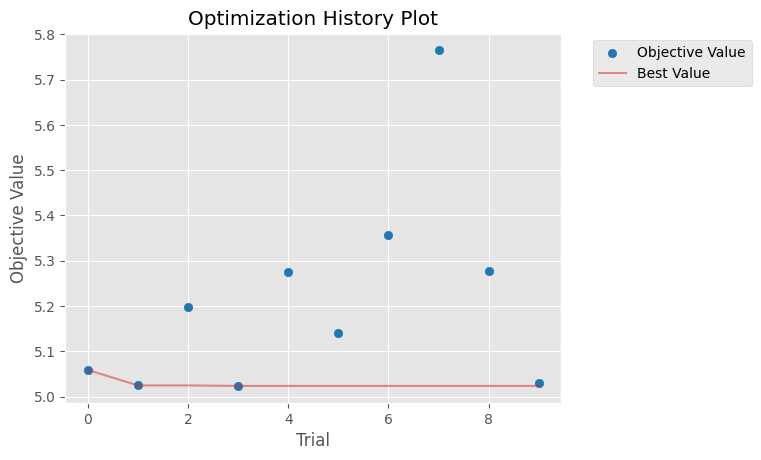

In [ ]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study)





## Ideas clave

- **Tracking**: cada entrenamiento es un *run*.
  - Dentro del run, en `Artifacts`, puedes tener un modelo loggeado (por ejemplo `Artifacts/model`).

- **Registry**: es un “catálogo” por **nombre de modelo**.
  - Un mismo nombre (por ejemplo `nyc-taxi-duration-model`) puede tener versiones **v1, v2, v3...**
  - Cada versión apunta al run que la generó.

## ¿Qué vamos a hacer aquí?

1) Re-entrenar el mejor modelo (ya lo hicimos arriba).
2) Loggear el pipeline (preproceso + modelo) como artifact.
3) (Opcional) Crear/actualizar una **nueva versión** en el Registry con `registered_model_name=...`.
4) Asignar aliases:
- `candidate`: versión nueva (la que estás probando)
- `champion`: versión estable (la “mejor” aprobada)


# **Usando el model registry para guardar el mejor modelo y "ponerlo" en producción**

Podemos usar autlog de sklearn para captar la mayor cantidad de parametros y asi tener un modelo altamente replicable

La importancia del model registry es ya no solamente pensar en la experimentación, sino que al final, después de haber encontrado el mejor modelo pushearlo a nuestro model registry y poder usarlo en producción.

In [ ]:
# Register + promote the best model (Model Registry)

import mlflow
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature
from sklearn.pipeline import Pipeline

client = MlflowClient()

# Creamos un pipeline completo para producción (preprocessor + model)
pipeline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model),
])

# Ejemplo para inferir signature (usamos una muestra pequeña de validación)
X_val_sample = df_val.head(50).copy()
X_val_sample["categorical_dict"] = X_val_sample[categorical].to_dict(orient="records")

# El pipeline espera el DF con la columna 'categorical_dict' y la numérica original
pred_sample = pipeline_model.predict(X_val_sample)
signature = infer_signature(X_val_sample, pred_sample)

registered_name = "nyc-taxi-duration-model"

with mlflow.start_run(run_name="register_best_model") as run:
    mlflow.set_tag("stage", "register")
    mlflow.log_metric("rmse_val", rmse_best)

    model_info = mlflow.sklearn.log_model(
        sk_model=pipeline_model,
        name="model",
        signature=signature,
        input_example=X_val_sample,
        registered_model_name=registered_name,
    )

model_uri = model_info.model_uri
print(f"Model URI: {model_uri}")

# Obtener la version recién creada
latest_versions = client.get_latest_versions(registered_name)
new_version = max(int(v.version) for v in latest_versions)
print(f"New version: {new_version}")

# Stages (flujo clásico)
client.transition_model_version_stage(
    name=registered_name,
    version=str(new_version),
    stage="Staging",
    archive_existing_versions=False,
)

# NO asignamos aliases automáticamente
print(f"Version {new_version} registered successfully")
print("You can manually assign aliases later:")
print(f"  - Set as champion: client.set_registered_model_alias('{registered_name}', 'champion', '{new_version}')")
print(f"  - Set as candidate: client.set_registered_model_alias('{registered_name}', 'candidate', '{new_version}')")

print({"registered_name": registered_name, "version": new_version, "model_uri": model_uri})

/Users/mdurango/Downloads/proyectos/MLOps_UdM/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/17 20:55:09 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 20:55:09 INFO mlflow.system_metrics.system_metrics_moni

🏃 View run register_best_model at: http://127.0.0.1:5000/#/experiments/5/runs/06ac8e55501d44548c9b05f2083a2cfc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
Model URI: models:/m-c33f9c7e4ff14dc49a47fa47bf44d07c
New version: 1
Version 1 registered successfully
You can manually assign aliases later:
  - Set as champion: client.set_registered_model_alias('nyc-taxi-duration-model', 'champion', '1')
  - Set as candidate: client.set_registered_model_alias('nyc-taxi-duration-model', 'candidate', '1')
{'registered_name': 'nyc-taxi-duration-model', 'version': 1, 'model_uri': 'models:/m-c33f9c7e4ff14dc49a47fa47bf44d07c'}


In [35]:
client.set_registered_model_alias(registered_name, "champion", "1")  # La mejor

In [36]:
client = MlflowClient()
model = client.get_registered_model(registered_name)
print(model.aliases)  # {'champion': '6', 'candidate': '3'}

{'champion': '1'}


In [37]:
# Obtener qué versión tiene el alias "champion"
champion_version = client.get_model_version_by_alias(registered_name, "champion")
print(champion_version.version)  # Ejemplo: "6"

1


In [38]:
client.transition_model_version_stage(registered_name, champion_version.version, "Staging")

/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_4449/3397019788.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(registered_name, champion_version.version, "Staging")


<ModelVersion: aliases=['champion'], creation_timestamp=1773798911176, current_stage='Staging', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1773799323906, metrics=None, model_id=None, name='nyc-taxi-duration-model', params=None, run_id='06ac8e55501d44548c9b05f2083a2cfc', run_link='', source='models:/m-c33f9c7e4ff14dc49a47fa47bf44d07c', status='READY', status_message=None, tags={}, user_id='', version='1'>

### Obtener modelo por versión:

In [40]:
model_uri = "models:/nyc-taxi-duration-model/1"
model = mlflow.sklearn.load_model(model_uri)

In [41]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', DictVectorizer(),
                                                  'categorical_dict'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=14, min_samples_split=10,
                                       n_estimators=89, n_jobs=-1,
                                       random_state=42))])

## Obtener el modelo usando el alias.version

In [ ]:
champion_version = client.get_model_version_by_alias("nyc-taxi-duration-model", "champion")
model_uri = f"models:/nyc-taxi-duration-model/{champion_version.version}"
model = mlflow.sklearn.load_model(model_uri)

In [43]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', DictVectorizer(),
                                                  'categorical_dict'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=14, min_samples_split=10,
                                       n_estimators=89, n_jobs=-1,
                                       random_state=42))])

### Obtener modelo por stage (Staging, production, a)

None → Staging → Production → Archived
 🔬       🧪         🚀          📦

In [44]:
model_uri = "models:/nyc-taxi-duration-model/Staging"
model = mlflow.sklearn.load_model(model_uri)

In [45]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', DictVectorizer(),
                                                  'categorical_dict'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=14, min_samples_split=10,
                                       n_estimators=89, n_jobs=-1,
                                       random_state=42))])

In [48]:
model.predict(X_val_sample)

array([24.45880252, 26.90198448, 30.64829834, 18.26878352, 15.12216544,
       12.85506025, 12.71131372,  7.42764372, 13.41694079, 10.15278053,
        4.06244564, 20.94048401,  9.66245783,  4.53941289, 17.03454223,
       16.59862655, 11.59506747,  3.65960152, 11.26979122,  8.62272724,
       23.61594958, 14.5969577 , 18.22045575, 13.77879642, 13.13930231,
       18.38631174, 19.8425579 , 11.77241818,  5.01862885, 21.19413813,
       17.93490694, 23.63574719,  8.54063936, 13.29455434, 13.96231291,
       14.05666942, 22.80305381, 17.36860981,  8.6430048 , 17.70741061,
        8.54162416,  4.72889615,  6.7377916 , 23.29100705, 13.06220093,
        3.93352493, 13.67666758,  6.73599973, 30.63184428, 20.23080445])